In [1]:
!pip install -q timm==1.0.11
!pip install -q peft==0.13.2
!pip install -q torchmetrics==1.4.2
!pip install -q scikit-learn==1.5.2
!pip install -q tqdm==4.66.5

print("Dependencies installed successfully.")

Dependencies installed successfully.


In [2]:
import os
import time
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

import timm
from peft import LoraConfig, get_peft_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    cohen_kappa_score,
)

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

print(f"PyTorch version : {torch.__version__}")
print(f"timm version     : {timm.__version__}")

PyTorch version : 2.10.0+cu128
timm version     : 1.0.11


In [3]:
# 3. Reproducibility & Device Configuration
SEED = 42

def set_seed(seed: int = SEED) -> None:
    """Fix random seeds across all relevant libraries for reproducible runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    print(f"GPU Name        : {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory (GB) : {torch.cuda.get_device_properties(0).total_memory / (1024**3):.2f}")
    print(f"CUDA Version    : {torch.version.cuda}")
else:
    print("WARNING: No GPU detected. Enable a GPU accelerator in Kaggle's notebook settings.")

torch.backends.cudnn.benchmark = True


Using device: cuda
GPU Name        : Tesla T4
GPU Memory (GB) : 14.56
CUDA Version    : 12.8


In [4]:
import os

print(os.listdir("/kaggle/input"))

['datasets']


In [5]:
import os

DATASET = "/kaggle/input"

for folder in os.listdir(DATASET):
    print(folder)
    try:
        print(os.listdir(os.path.join(DATASET, folder))[:20])
    except:
        pass

datasets
['mariaherrerot']


In [6]:
# Load Dataset
DATA_DIR = "/kaggle/input/datasets/mariaherrerot/aptos2019"

TRAIN_CSV = os.path.join(DATA_DIR, "train_1.csv")
VALID_CSV = os.path.join(DATA_DIR, "valid.csv")

TRAIN_IMG_DIR = os.path.join(DATA_DIR, "train_images", "train_images")
VALID_IMG_DIR = os.path.join(DATA_DIR, "val_images", "val_images")

train_df = pd.read_csv(TRAIN_CSV)
valid_df = pd.read_csv(VALID_CSV)

train_df["file_path"] = train_df["id_code"].apply(lambda x: os.path.join(TRAIN_IMG_DIR, f"{x}.png"))
valid_df["file_path"] = valid_df["id_code"].apply(lambda x: os.path.join(VALID_IMG_DIR, f"{x}.png"))

print(f"Train samples: {len(train_df)}")
print(f"Valid samples: {len(valid_df)}")
train_df.head()

Train samples: 2930
Valid samples: 366


,id_code,diagnosis,file_path
0,1ae8c165fd53,2,/kaggle/input/datasets/mariaherrerot/aptos2019...
1,1b329a127307,1,/kaggle/input/datasets/mariaherrerot/aptos2019...
2,1b32e1d775ea,4,/kaggle/input/datasets/mariaherrerot/aptos2019...
3,1b3647865779,0,/kaggle/input/datasets/mariaherrerot/aptos2019...
4,1b398c0494d1,0,/kaggle/input/datasets/mariaherrerot/aptos2019...


Training class distribution:
  0 (No DR            ):  1434 images (48.94%)
  1 (Mild             ):   300 images (10.24%)
  2 (Moderate         ):   808 images (27.58%)
  3 (Severe           ):   154 images (5.26%)
  4 (Proliferative DR ):   234 images (7.99%)


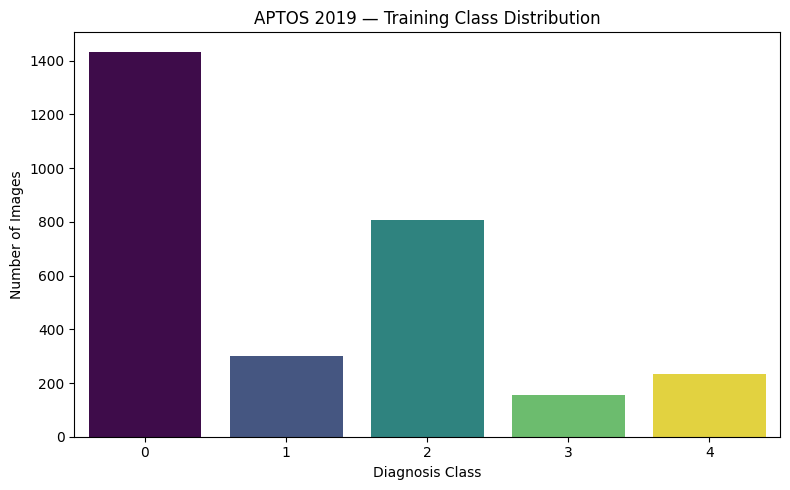

In [7]:
CLASS_NAMES = {
    0: "No DR",
    1: "Mild",
    2: "Moderate",
    3: "Severe",
    4: "Proliferative DR",
}

class_counts = train_df["diagnosis"].value_counts().sort_index()

print("Training class distribution:")
for cls_idx, count in class_counts.items():
    print(f"  {cls_idx} ({CLASS_NAMES[cls_idx]:<17}): {count:5d} images "
          f"({100 * count / len(train_df):.2f}%)")

plt.figure(figsize=(8, 5))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index,
            palette="viridis", legend=False)
plt.xlabel("Diagnosis Class")
plt.ylabel("Number of Images")
plt.title("APTOS 2019 — Training Class Distribution")
plt.tight_layout()
plt.show()

In [8]:
# 5. Image Preprocessing & Augmentation

IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.05),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

valid_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

print("Train transform:\n", train_transform)
print("\nValid transform:\n", valid_transform)


Train transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.5)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.8, 1.2), contrast=(0.8, 1.2), saturation=(0.8, 1.2), hue=(-0.05, 0.05))
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Valid transform:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [9]:
# 6. Custom Dataset Class

class APTOSDataset(Dataset):
    """PyTorch Dataset wrapper for the APTOS 2019 Blindness Detection data."""

    def __init__(self, dataframe: pd.DataFrame, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self) -> int:
        return len(self.df)

    def __getitem__(self, idx: int):
        row = self.df.loc[idx]
        img_path = row["file_path"]
        label = int(row["diagnosis"])

        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = APTOSDataset(train_df, transform=train_transform)
valid_dataset = APTOSDataset(valid_df, transform=valid_transform)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Valid dataset size: {len(valid_dataset)}")

sample_image, sample_label = train_dataset[0]
print(f"Sample image shape: {sample_image.shape} | label: {sample_label}")


Train dataset size: 2930
Valid dataset size: 366
Sample image shape: torch.Size([3, 224, 224]) | label: 2


In [10]:
# 7. DataLoaders

BATCH_SIZE = 32
NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    drop_last=True,
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
)

print(f"Train batches: {len(train_loader)} | Valid batches: {len(valid_loader)}")

images, labels = next(iter(train_loader))
print(f"Batch image shape: {images.shape} | Batch label shape: {labels.shape}")


Train batches: 91 | Valid batches: 12
Batch image shape: torch.Size([32, 3, 224, 224]) | Batch label shape: torch.Size([32])


In [11]:
# 8. Swin Transformer Model + LoRA adapters

NUM_CLASSES = 5

base_swin_model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
)

# ------------------------------------------------------------------
# LoRA configuration for timm Swin Transformer
# ------------------------------------------------------------------
# Verified against the live architecture: every WindowAttention block
# (layers.{0..3}.blocks.{i}.attn) exposes `qkv` (fused query/key/value,
# nn.Linear) and `proj` (attention output projection, nn.Linear) - the
# correct LoRA injection points, same role as in MaxViT.
#
# UNLIKE MaxViT, a plain target_modules=["qkv","proj"] name list is
# wrong here: Swin's patch-embedding stem (patch_embed.proj) is an
# nn.Conv2d that also ends in ".proj", and a bare suffix match would
# silently attach LoRA to it too, defeating "freeze the backbone."
# The regex below anchors on ".attn.qkv"/".attn.proj" specifically, so
# it matches only the 48 real attention projections (2+2+18+2 blocks
# x 2 layers each) and excludes patch_embed entirely.
lora_config = LoraConfig(
    r=16,
    lora_alpha=32,
    target_modules=r".*attn\.(qkv|proj)$",
    lora_dropout=0.1,
    bias="none",
    modules_to_save=["head.fc"],  # classifier head stays fully trainable
)

swin_model = get_peft_model(base_swin_model, lora_config)
swin_model = swin_model.to(device)

# ------------------------------------------------------------------
# Parameter accounting
# ------------------------------------------------------------------
total_params = sum(p.numel() for p in swin_model.parameters())
trainable_params = sum(p.numel() for p in swin_model.parameters() if p.requires_grad)

print(f"Model                : swin_base_patch4_window7_224 + LoRA (r={lora_config.r}, alpha={lora_config.lora_alpha})")
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Percentage trainable : {100 * trainable_params / total_params:.4f}%")

swin_model.print_trainable_parameters()

# Quick forward-pass sanity check
sample_images, _ = next(iter(train_loader))
with torch.no_grad():
    sample_outputs = swin_model(sample_images.to(device))
print(f"Sample output shape : {sample_outputs.shape}")

Model                : swin_base_patch4_window7_224 + LoRA (r=16, alpha=32)
Total parameters     : 87,908,546
Trainable parameters : 1,160,197
Percentage trainable : 1.3198%
trainable params: 1,160,197 || all params: 87,908,546 || trainable%: 1.3198
Sample output shape : torch.Size([32, 5])


In [12]:
#  9. Loss, Optimizer & Scheduler

criterion = nn.CrossEntropyLoss()

# LoRA adapters start from a small random init and need a higher LR
# than full fine-tuning to converge in the same number of epochs.
# AdamW is kept as requested; only the LR changes.
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
EPOCHS = 15

# Only LoRA + head.fc params have requires_grad=True - filtering keeps
# AdamW's optimizer state limited to the ~1.3% of params being trained.
trainable_params = [p for p in swin_model.parameters() if p.requires_grad]

optimizer = optim.AdamW(
    trainable_params,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)

scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=EPOCHS,
)

BEST_MODEL_PATH = "best_swin_lora.pth"
CHECKPOINT_PATH = "swin_lora_checkpoint.pth"

# Guardrail: confirm optimizer only holds trainable params
optimizer_param_ids = {id(p) for group in optimizer.param_groups for p in group["params"]}
trainable_param_ids = {id(p) for p in swin_model.parameters() if p.requires_grad}
assert optimizer_param_ids == trainable_param_ids, "Optimizer is not bound to swin_model's trainable parameters!"

print("Loss Function :", criterion)
print("Optimizer     : AdamW (LoRA + head.fc params only)")
print("Scheduler     : CosineAnnealingLR")
print("Epochs        :", EPOCHS)
print("Best ckpt     :", BEST_MODEL_PATH)
print("Rolling ckpt  :", CHECKPOINT_PATH)
print("Optimizer <-> trainable parameter check passed.")

Loss Function : CrossEntropyLoss()
Optimizer     : AdamW (LoRA + head.fc params only)
Scheduler     : CosineAnnealingLR
Epochs        : 15
Best ckpt     : best_swin_lora.pth
Rolling ckpt  : swin_lora_checkpoint.pth
Optimizer <-> trainable parameter check passed.


In [13]:
# 10. Training & Validation Functions

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training", leave=False)

    for images, labels in progress_bar:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        progress_bar.set_postfix(loss=loss.item(), acc=100 * correct / total)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc


def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc, all_labels, all_preds


print("train_one_epoch and validate functions defined.")


train_one_epoch and validate functions defined.


In [14]:
# 11. Training Loop

best_accuracy = 0.0
best_qwk = -1.0

train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(swin_model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc, y_true, y_pred = validate(swin_model, valid_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    epoch_qwk = cohen_kappa_score(y_true, y_pred, weights="quadratic")

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Valid Acc  : {valid_acc:.4f}")
    print(f"Valid QWK  : {epoch_qwk:.4f}")

    # Rolling checkpoint every epoch - full model state (frozen backbone
    # + LoRA deltas + head), reloadable with a plain load_state_dict
    torch.save({
        "epoch": epoch + 1,
        "model_state_dict": swin_model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "train_loss": train_loss,
        "valid_loss": valid_loss,
        "valid_acc": valid_acc,
        "valid_qwk": epoch_qwk,
    }, CHECKPOINT_PATH)

    if valid_acc > best_accuracy:
        best_accuracy = valid_acc
        best_qwk = epoch_qwk
        torch.save(swin_model.state_dict(), BEST_MODEL_PATH)
        print("Best Swin LoRA model saved!")

print("\nSwin Transformer LoRA Training Complete!")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")
print(f"Best Validation QWK     : {best_qwk:.4f}")


Epoch 1/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 1.0569
Train Acc  : 0.5948
Valid Loss : 0.7580
Valid Acc  : 0.7131
Valid QWK  : 0.7466
Best Swin LoRA model saved!

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 0.6154
Train Acc  : 0.7641
Valid Loss : 0.5970
Valid Acc  : 0.7787
Valid QWK  : 0.8510
Best Swin LoRA model saved!

Epoch 3/15
----------------------------------------


...

Training:   0%|          | 0/91 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d91fb860d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d91fb860d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss : 0.3820
Train Acc  : 0.8571
Valid Loss : 0.4798
Valid Acc  : 0.8142
Valid QWK  : 0.8828

Epoch 15/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 0.3842
Train Acc  : 0.8599
Valid Loss : 0.4799
Valid Acc  : 0.8142
Valid QWK  : 0.8810

Swin Transformer LoRA Training Complete!
Best Validation Accuracy: 0.8197
Best Validation QWK     : 0.8860


In [15]:
# 11. Training Loop

best_accuracy = 0.0

train_losses = []
valid_losses = []
train_accuracies = []
valid_accuracies = []

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(swin_model, train_loader, criterion, optimizer, device)
    valid_loss, valid_acc, y_true, y_pred = validate(swin_model, valid_loader, criterion, device)

    scheduler.step()

    train_losses.append(train_loss)
    valid_losses.append(valid_loss)
    train_accuracies.append(train_acc)
    valid_accuracies.append(valid_acc)

    print(f"Train Loss : {train_loss:.4f}")
    print(f"Train Acc  : {train_acc:.4f}")
    print(f"Valid Loss : {valid_loss:.4f}")
    print(f"Valid Acc  : {valid_acc:.4f}")

    if valid_acc > best_accuracy:
        best_accuracy = valid_acc
        torch.save(swin_model.state_dict(), BEST_MODEL_PATH)
        print("Best Swin model saved!")

print("\nSwin Transformer Training Complete!")
print(f"Best Validation Accuracy: {best_accuracy:.4f}")



Epoch 1/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d91fb860d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d91fb860d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss : 0.3756
Train Acc  : 0.8558
Valid Loss : 0.4799
Valid Acc  : 0.8142
Best Swin model saved!

Epoch 2/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

...

Training:   0%|          | 0/91 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d91fb860d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1690, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7d91fb860d60>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1707, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Train Loss : 0.3556
Train Acc  : 0.8661
Valid Loss : 0.4556
Valid Acc  : 0.8306
Best Swin model saved!

Epoch 15/15
----------------------------------------


Training:   0%|          | 0/91 [00:00<?, ?it/s]

Train Loss : 0.3641
Train Acc  : 0.8620
Valid Loss : 0.4899
Valid Acc  : 0.8224

Swin Transformer Training Complete!
Best Validation Accuracy: 0.8306


Evaluating:   0%|          | 0/12 [00:00<?, ?it/s]

VALIDATION SET — EVALUATION SUMMARY (Swin Transformer)
Accuracy               : 0.8306
Precision (weighted)   : 0.8175
Recall (weighted)      : 0.8306
F1-Score (weighted)    : 0.8076
Quadratic Weighted Kappa (QWK): 0.8866

Classification Report:

                  precision    recall  f1-score   support

           No DR       0.98      0.99      0.99       172
            Mild       0.74      0.57      0.65        40
        Moderate       0.70      0.90      0.79       104
          Severe       0.50      0.05      0.08        22
Proliferative DR       0.62      0.54      0.58        28

        accuracy                           0.83       366
       macro avg       0.71      0.61      0.62       366
    weighted avg       0.82      0.83      0.81       366



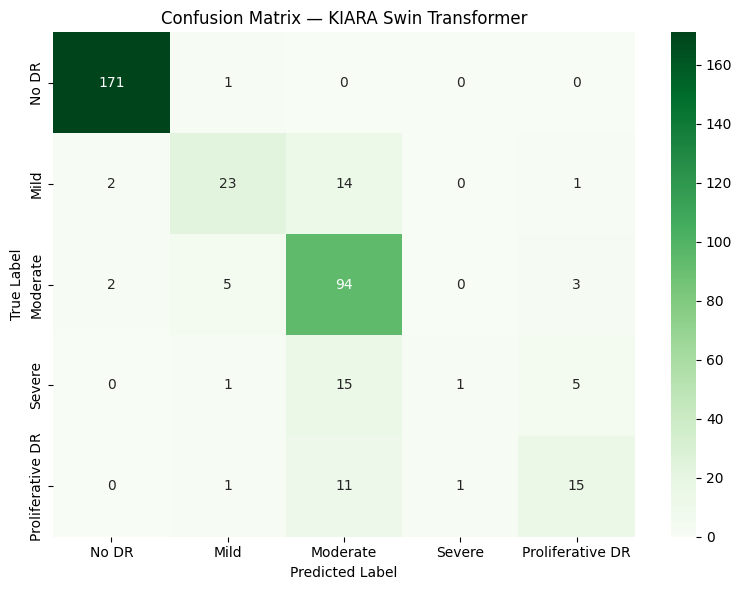

In [16]:
# 12. Comprehensive Evaluation

swin_model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
swin_model.eval()

all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in tqdm(valid_loader, desc="Evaluating"):
        images = images.to(device)
        outputs = swin_model(images)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

acc = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average="weighted", zero_division=0)
recall = recall_score(all_labels, all_preds, average="weighted", zero_division=0)
f1 = f1_score(all_labels, all_preds, average="weighted", zero_division=0)
qwk = cohen_kappa_score(all_labels, all_preds, weights="quadratic")

print("=" * 55)
print("VALIDATION SET — EVALUATION SUMMARY (Swin Transformer)")
print("=" * 55)
print(f"Accuracy               : {acc:.4f}")
print(f"Precision (weighted)   : {precision:.4f}")
print(f"Recall (weighted)      : {recall:.4f}")
print(f"F1-Score (weighted)    : {f1:.4f}")
print(f"Quadratic Weighted Kappa (QWK): {qwk:.4f}")
print("=" * 55)

print("\nClassification Report:\n")
print(classification_report(
    all_labels, all_preds,
    target_names=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
    zero_division=0,
))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens",
            xticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)],
            yticklabels=[CLASS_NAMES[i] for i in range(NUM_CLASSES)])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — KIARA Swin Transformer")
plt.tight_layout()
plt.show()


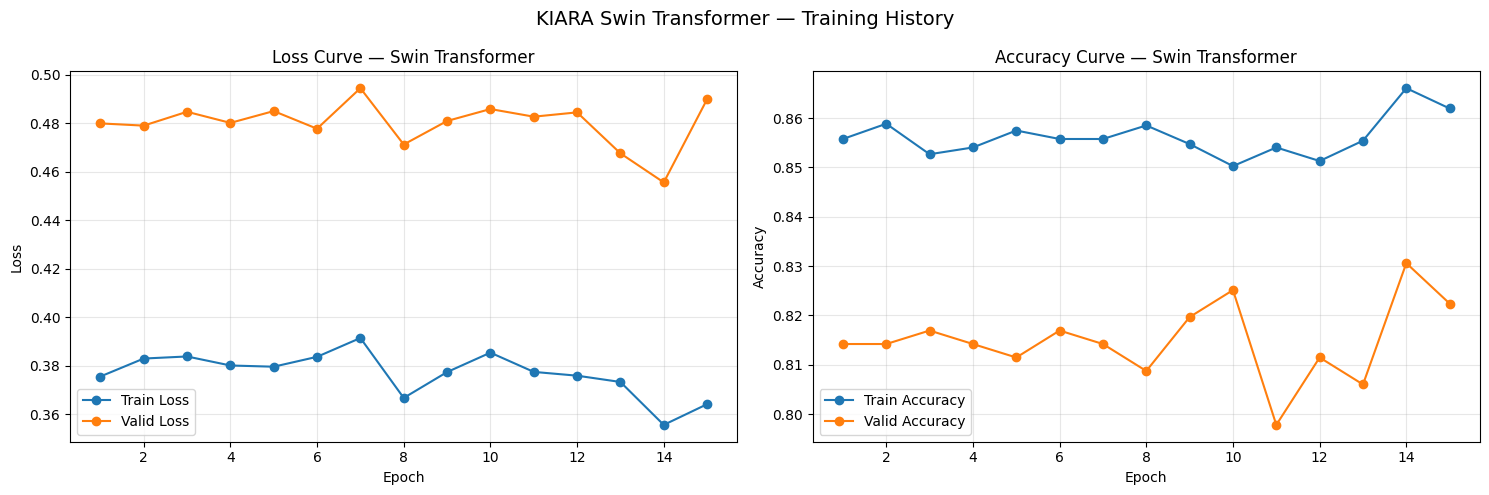

In [17]:
# # 13. Training Curves

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
epochs_range = range(1, len(train_losses) + 1)

axes[0].plot(epochs_range, train_losses, label="Train Loss", marker="o")
axes[0].plot(epochs_range, valid_losses, label="Valid Loss", marker="o")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss Curve — Swin Transformer")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, train_accuracies, label="Train Accuracy", marker="o")
axes[1].plot(epochs_range, valid_accuracies, label="Valid Accuracy", marker="o")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy Curve — Swin Transformer")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.suptitle("KIARA Swin Transformer — Training History", fontsize=14)
plt.tight_layout()
plt.show()


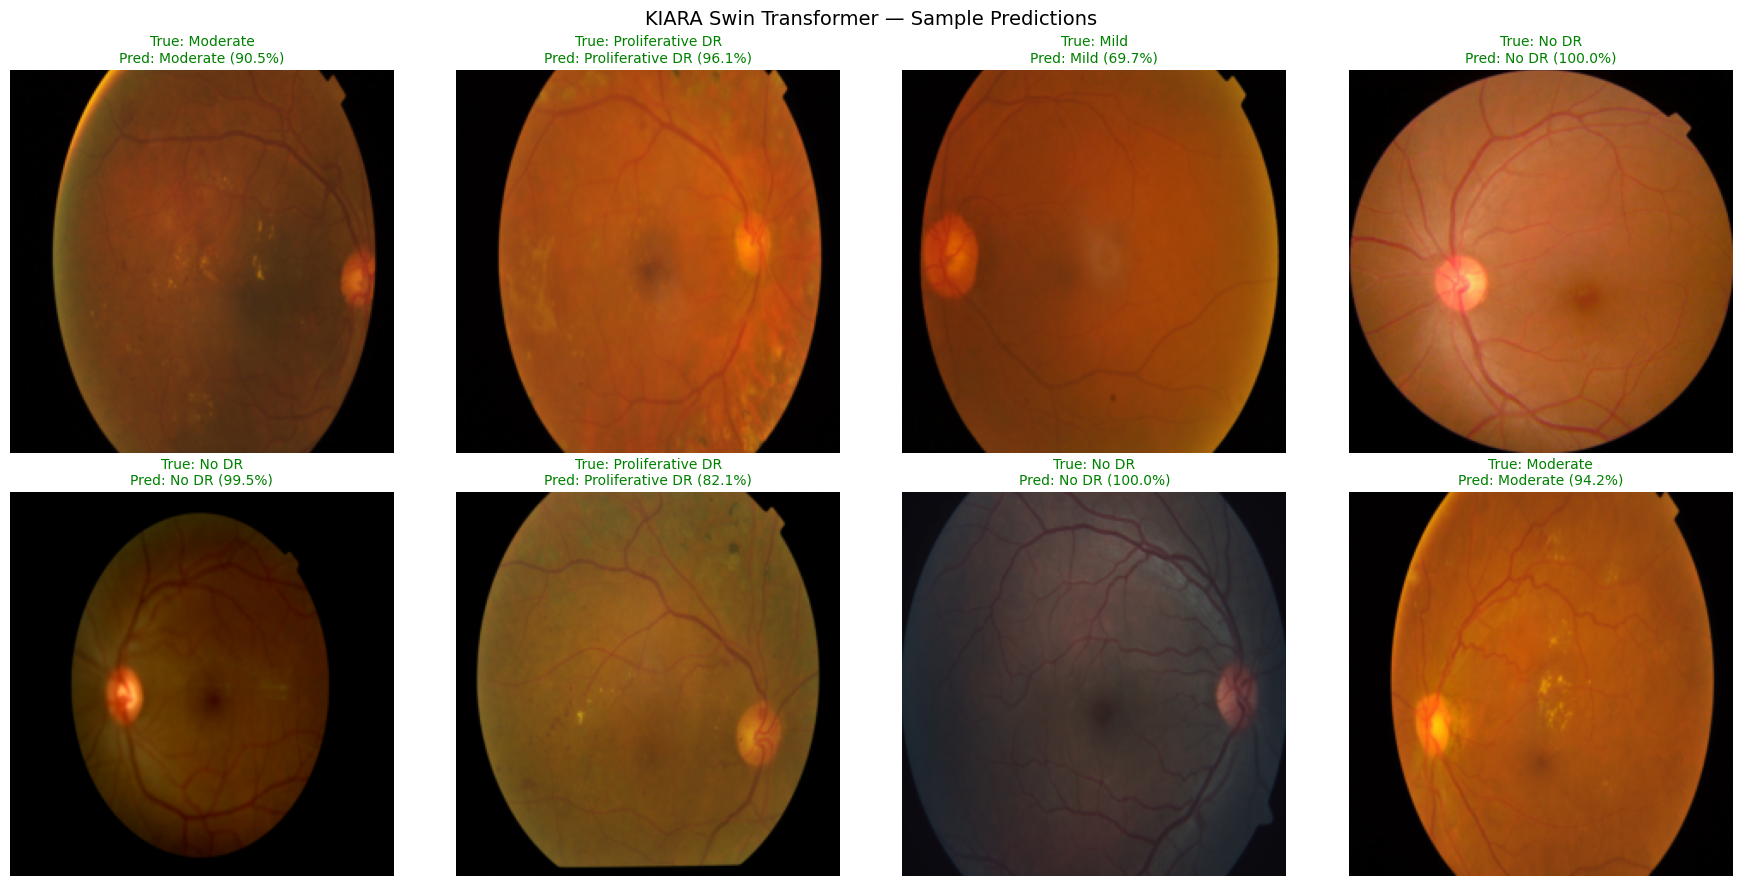

In [18]:
# 14. Prediction Visualization

def denormalize(tensor_img, mean=IMAGENET_MEAN, std=IMAGENET_STD):
    img = tensor_img.clone().cpu().numpy().transpose(1, 2, 0)
    img = img * np.array(std) + np.array(mean)
    return np.clip(img, 0, 1)


vis_images, vis_labels = next(iter(valid_loader))
vis_images_device = vis_images.to(device)

swin_model.eval()
with torch.no_grad():
    outputs = swin_model(vis_images_device)
    probs = torch.softmax(outputs, dim=1)
    confidences, preds = torch.max(probs, dim=1)

n_display = min(8, len(vis_images))
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i in range(n_display):
    img = denormalize(vis_images[i])
    true_label = vis_labels[i].item()
    pred_label = preds[i].item()
    confidence = confidences[i].item()

    color = "green" if true_label == pred_label else "red"

    axes[i].imshow(img)
    axes[i].axis("off")
    axes[i].set_title(
        f"True: {CLASS_NAMES[true_label]}\nPred: {CLASS_NAMES[pred_label]} ({confidence*100:.1f}%)",
        color=color, fontsize=10,
    )

plt.suptitle("KIARA Swin Transformer — Sample Predictions", fontsize=14)
plt.tight_layout()
plt.show()


In [19]:
# 15. Final model
FINAL_MODEL_PATH = "kiara_swin_lora_final.pth"

torch.save(swin_model.state_dict(), FINAL_MODEL_PATH)

torch.save({
    "model_state_dict": swin_model.state_dict(),
    "model_name": "swin_base_patch4_window7_224",
    "lora_r": lora_config.r,
    "lora_alpha": lora_config.lora_alpha,
    "lora_target_modules": lora_config.target_modules,
    "num_classes": NUM_CLASSES,
    "class_names": CLASS_NAMES,
    "img_size": IMG_SIZE,
    "imagenet_mean": IMAGENET_MEAN,
    "imagenet_std": IMAGENET_STD,
    "best_val_accuracy": float(best_accuracy),
    "qwk": float(qwk),
}, "kiara_swin_lora_checkpoint.pth")

print(f"Final model weights saved to : {FINAL_MODEL_PATH}")
print("Rich checkpoint saved to      : kiara_swin_lora_checkpoint.pth")

Final model weights saved to : kiara_swin_lora_final.pth
Rich checkpoint saved to      : kiara_swin_lora_checkpoint.pth


In [1]:
import os

for f in os.listdir("/kaggle/working"):
    size = os.path.getsize(f"/kaggle/working/{f}") / (1024 * 1024)
    print(f"{f}  ({size:.2f} MB)")

.virtual_documents  (0.00 MB)
